In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv("ai4i2020.csv")

print("Original Columns:")
print(df.columns.tolist())

Original Columns:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [3]:
columns_to_drop = [col for col in ['UDI', 'Product ID'] if col in df.columns]
df = df.drop(columns=columns_to_drop)

if 'Type' in df.columns:
    type_mapping = {'L': 0, 'M': 1, 'H': 2}
    df['Type'] = df['Type'].map(type_mapping)
    print("Successfully encoded 'Type' column.")
else:
    print("Warning: 'Type' column not found or already processed.")

df.head()

Successfully encoded 'Type' column.


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,0,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,0,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,0,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,0,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


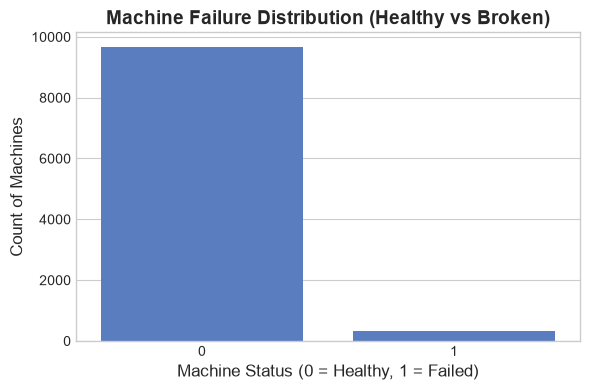

In [5]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

# Graph 1: Number of Failed Machines
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Machine failure')
plt.title('Machine Failure Distribution (Healthy vs Broken)', fontsize=14, fontweight='bold')
plt.xlabel('Machine Status (0 = Healthy, 1 = Failed)', fontsize=12)
plt.ylabel('Count of Machines', fontsize=12)
plt.tight_layout()
plt.savefig('01_machine_failure_count.png', dpi=300)
plt.show()

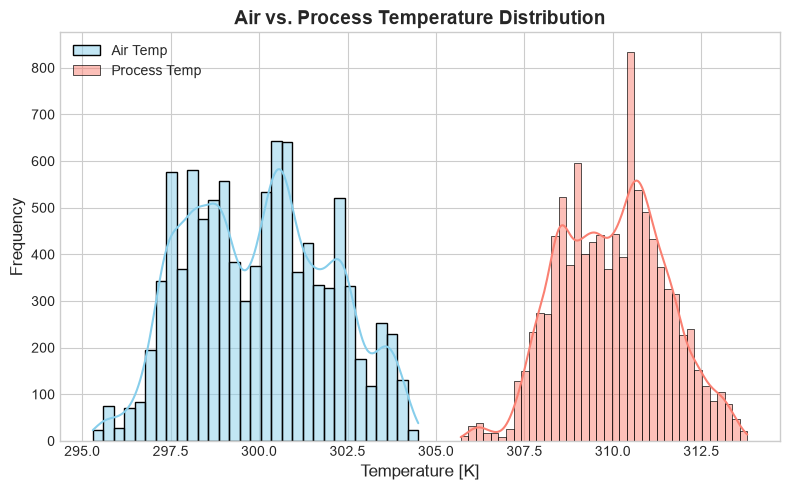

In [6]:
# Graph 2: Temperature Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Air temperature [K]', color='skyblue', label='Air Temp', kde=True)
sns.histplot(data=df, x='Process temperature [K]', color='salmon', label='Process Temp', kde=True)
plt.title('Air vs. Process Temperature Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Temperature [K]', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('02_temperature_distribution.png', dpi=300)
plt.show()

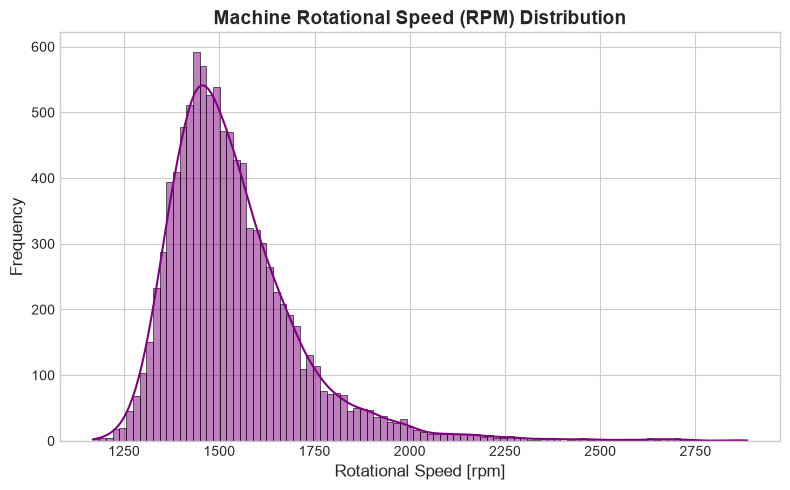

In [7]:
# Graph 3: RPM Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Rotational speed [rpm]', color='purple', kde=True)
plt.title('Machine Rotational Speed (RPM) Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Rotational Speed [rpm]', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.savefig('03_rpm_distribution.png', dpi=300)
plt.show()

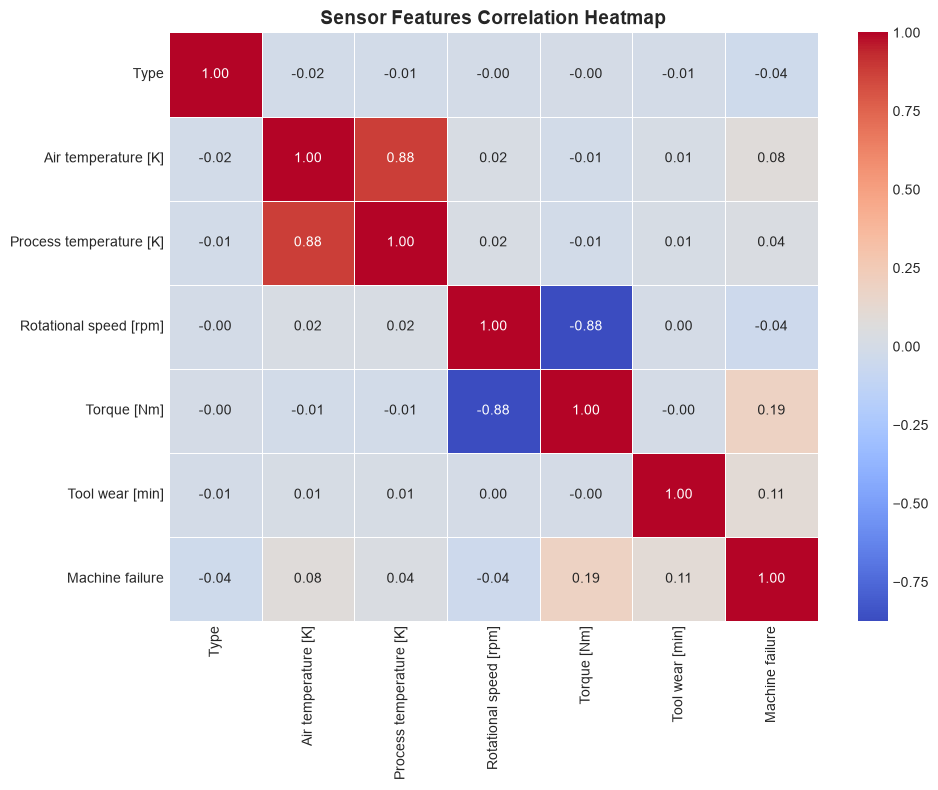

In [9]:
#Graph 4: Correlation Heatmap (Including our new Type column)
plt.figure(figsize=(10, 8))
numeric_cols = ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Sensor Features Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=300)
plt.show()

In [10]:
#splitting features (X)(all sensor/type attributes) and target (y)(machine failure)
X = df.drop(columns=['Machine failure'])
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Data Split Summary:")
print(f"Total dataset shape: {df.shape}")
print(f"Training features (X_train) shape: {X_train.shape} (80%)")
print(f"Testing features (X_test) shape: {X_test.shape} (20%)")
print(f"Failure balance in training set:\n{y_train.value_counts(normalize=True)}")

Data Split Summary:
Total dataset shape: (10000, 12)
Training features (X_train) shape: (8000, 11) (80%)
Testing features (X_test) shape: (2000, 11) (20%)
Failure balance in training set:
Machine failure
0    0.966125
1    0.033875
Name: proportion, dtype: float64
